<a href="https://colab.research.google.com/github/Jaydenkaleb/Introduction-to-AI/blob/main/Assignment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Choose a publicly available dataset suitable for a regression problem.

The Medical Cost dataset contains information about individuals' demographic and lifestyle characteristics, including age, sex, BMI, number of children, smoking status, and region.

In [44]:
# Medical_cost from Kaggle.
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)


In [15]:
#Load the dataset
df=pd.read_csv("Lesson_8_Medical_cost.csv")

In [16]:
df.head()

,age,sex,bmi,children,smoker,region,medical charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [17]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'medical charges'], dtype='object')

In [18]:
#check for null values
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
medical charges,0


In [19]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
medical charges,float64


In [20]:
#Clean the target Column Names to ensure no space inthe name
df = df.rename(columns={'medical charges': 'medical_charges'})
df.head()


,age,sex,bmi,children,smoker,region,medical_charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [21]:
#Check for duplicate
df.duplicated().sum()

np.int64(1)

In [22]:
#Drop duplicate
df = df.drop_duplicates()

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df.describe()

,age,bmi,children,medical_charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


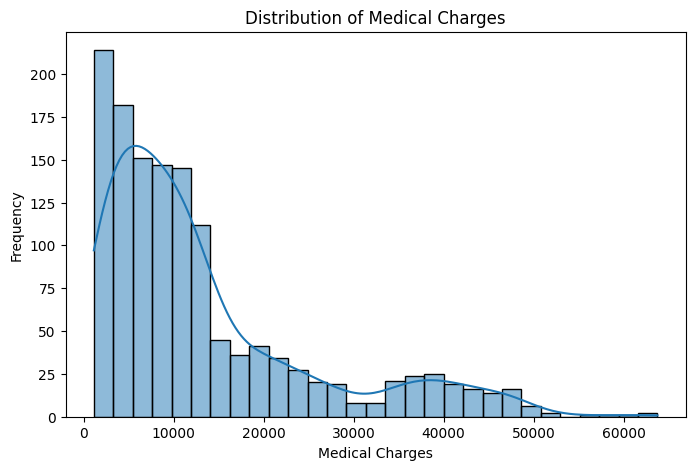

In [32]:
#Exploratory Data Analysis to determine teh skewness of the dataset before converting the medical charge into classification
plt.figure(figsize=(8, 5))

sns.histplot(df['medical_charges'], kde=True)

plt.title('Distribution of Medical Charges')
plt.xlabel('Medical Charges')
plt.ylabel('Frequency')

plt.show()

The medical charge is right skewed meaning a small number of people have higher higher medical charges

In [33]:
#because the assignemnt ask for a classification model, it implies the target variable should be categorical. As such, the medical charge will be converted into two class:
#0: low medical Chare representing the charge below teh median value
#1: Highe Medical Charge representing charges above the median value.

#Convert Medical Charges into a Classification Target
median_charge = df['medical_charges'].median()

print('median medical charge:',median_charge)


median medical charge: 9386.1613


In [34]:
#create the target
df['charge_class'] = np.where(
    df['medical_charges'] > median_charge,
    1,
    0
)

Any value above the median is classified as high medical charge
amnd any value below teh median is classified as low medical charge

In [35]:
#show the result
df[['medical_charges', 'charge_class']].head(10)

,medical_charges,charge_class
0,16884.92400,1
1,1725.55230,0
2,4449.46200,0
3,21984.47061,1
4,3866.85520,0
5,3756.62160,0
6,8240.58960,0
7,7281.50560,0
8,6406.41070,0
9,28923.13692,1


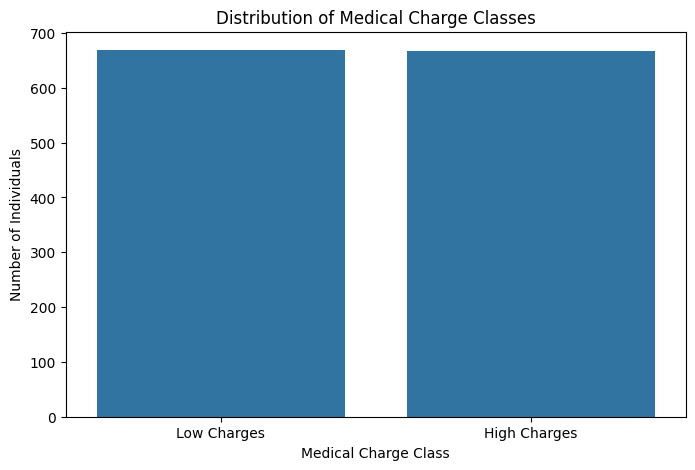

In [37]:
#View the Distribution of classes after converting the medical charge to categorical.
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='charge_class')

plt.title('Distribution of Medical Charge Classes')
plt.xlabel('Medical Charge Class')
plt.ylabel('Number of Individuals')
plt.xticks([0, 1], ['Low Charges', 'High Charges'])

plt.show()

Both classess are almost even in the classification. Meaning it is a blanced dataset meaning we can rely on accuracy measure

In [45]:
#Encode Categorical Variables
categorical_features = ['sex', 'smoker', 'region']
numerical_features = ['age', 'bmi', 'children']
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)



In [46]:
#split data into training and testing
X = df.drop(columns=['medical_charges', 'charge_class'])

y = df['charge_class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (1069, 6)
Testing set: (268, 6)


In [48]:
#Logistic Regression
logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000))
    ]
)

#Train
logistic_model.fit(X_train, y_train)
#predict
y_pred_logistic = logistic_model.predict(X_test)

In [49]:
#Evaluate the Logistic Regression
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic)
logistic_recall = recall_score(y_test, y_pred_logistic)
logistic_f1 = f1_score(y_test, y_pred_logistic)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy:", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall:", logistic_recall)
print("F1 Score:", logistic_f1)

Logistic Regression Results
---------------------------
Accuracy: 0.9029850746268657
Precision: 0.8913043478260869
Recall: 0.917910447761194
F1 Score: 0.9044117647058824


In [50]:
#Random Forest
random_forest_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)

#Train the model
random_forest_model.fit(X_train, y_train)

#Predict
y_pred_rf = random_forest_model.predict(X_test)

In [51]:
#Evaluate the Random Forest model
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)

Random Forest Results
---------------------
Accuracy: 0.9365671641791045
Precision: 0.9606299212598425
Recall: 0.9104477611940298
F1 Score: 0.9348659003831418


In [52]:
#Compare both model
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [logistic_accuracy, rf_accuracy],
    'Precision': [logistic_precision, rf_precision],
    'Recall': [logistic_recall, rf_recall]
})



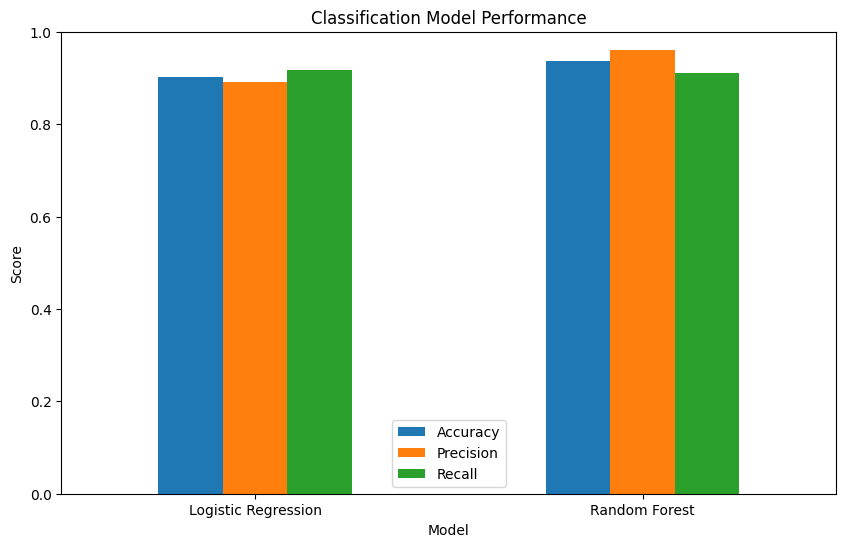

In [53]:
#Visualize the comparism
results.set_index('Model').plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Classification Model Performance')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.show()

Logistic Regression Results
Accuracy: 0.9029850746268657
Precision: 0.8913043478260869
Recall: 0.917910447761194
F1 Score: 0.9044117647058824

Random Forest Results
Accuracy: 0.9365671641791045
Precision: 0.9606299212598425
Recall: 0.9104477611940298
F1 Score: 0.9348659003831418

The Random Forest Classifier performed better overall than Logistic Regression. Random Forest achieved an accuracy of 93.66%, compared with 90.30% for Logistic Regression. It also achieved higher precision (96.06%) and F1-score (93.49%), indicating that it was more effective at correctly identifying individuals in the high medical charge class. Logistic Regression achieved a slightly higher recall of 91.79% compared with 91.04% for Random Forest, meaning it identified marginally more of the actual high-charge cases. However, the difference in recall was small. Overall, Random Forest perfomed better in dataset.

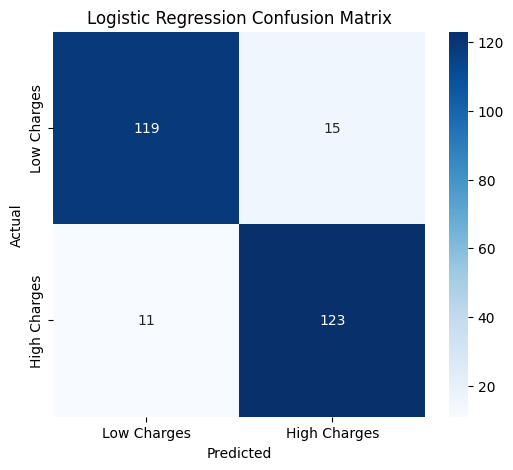

In [54]:
# confusion matrix for logisticregression
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low Charges', 'High Charges'],
    yticklabels=['Low Charges', 'High Charges']
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

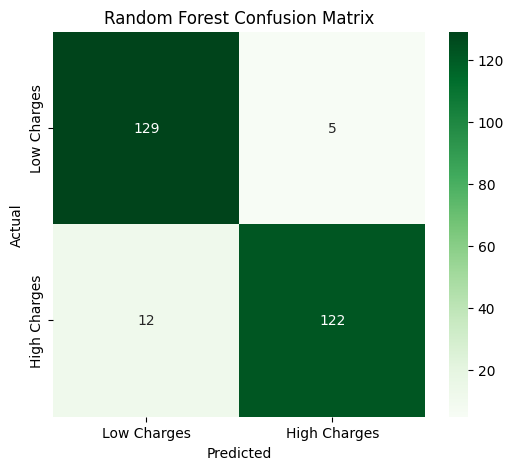

In [55]:
#Confusion matrix for random forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Low Charges', 'High Charges'],
    yticklabels=['Low Charges', 'High Charges']
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()